<a href="https://colab.research.google.com/github/dionatrafk/model_evaluation/blob/master/GRU_exec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gated Recurrent Unit (GRU)

In [ ]:
#Import datasets
!git clone https://github.com/dionatrafk/model_evaluation

*Execution options: **default 60 minute predictions.

**Copy a row of hyperparameters and paste into row 2 of the next cell.**


('trace60.csv', 130, 130, 128, 64),

In [1]:
#definir hiperparâmetros

path = './http_requests_nasa/'

hyperparameters = [
('trace1.csv', 140, 150, 8, 64),
('trace5.csv', 130, 130, 128, 64),
('trace10.csv', 140, 100, 16, 32),
('trace15.csv', 140, 190, 5, 40),
('trace20.csv', 140, 200, 50, 45),
('trace25.csv', 180, 200, 10, 80),
('trace30.csv', 140, 190, 5, 40 ),
('trace35.csv', 180, 200, 10, 80),
('trace40.csv', 130, 130, 256, 32),
('trace45.csv', 140, 150, 8, 64),
('trace50.csv', 130, 130, 60, 60),
('trace55.csv', 130, 130, 128, 64),
]

results = []

In [2]:
import pandas as pd
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, GRU
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math, datetime

def create_dataset(dataset, lookback=1):
    dataX, dataY = [], [] # create 2 empty lists

    # go through the lenght of dataset, subtract the lookback and 1. 2 steps before the end of dataset, 
    #because we predict 1 step to the future
    for i in range(len(dataset)-lookback-1):
        a = dataset[i:(i+lookback),0]
        dataX.append(a)
        dataY.append(dataset[i+lookback,0]) # get the next value
    return np.array(dataX), np.array(dataY)

def gru(filename, BATCH_SIZE, NB_EPOCHS, LAYER1, LAYER2):

    filename = path + filename

    #perc = float(sys.argv[6])
    # Dataset configuration
    dataset = pd.read_csv(filename, usecols = [1], header=None)
    dataset.columns = ["request"]
    dataset = dataset.values #convert to the array
    dataset = dataset.astype('float32') # convert to float

    # length of our dataset
    training_size = int(len(dataset)*0.67)
    testing_size = len(dataset)-training_size

    # split the data set
    train, test = dataset[0:training_size:], dataset[training_size:len(dataset),:]

    # one time step to the future
    lookback = 1
    trainX, trainY = create_dataset(train, lookback)
    testX, testY = create_dataset(test, lookback)

    # Scaling dataset
    scaleX = MinMaxScaler()
    scaleY = MinMaxScaler()

    trainX = scaleX.fit_transform(trainX)
    trainX = trainX.reshape((-1,1,1))

    trainY = scaleY.fit_transform(trainY.reshape(-1,1))

    testX  = scaleX.transform(testX)
    testX = testX.reshape((-1,1,1))

    testY  = scaleY.transform(testY.reshape(-1,1))

    # creating model using Keras
    model_name = 'requests_GRU'
    model = Sequential()
    model.add(GRU(units=LAYER1,
                return_sequences=True,
                input_shape=(1, 1)))
    model.add(Dropout(0.2))
    model.add(GRU(units=LAYER2))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    #test with less samples	
    #size = int(training_size * (perc /100))
    #trainX = trainX[0:training_size - size:]
    #trainY = trainY[0:training_size - size:]
    timer = datetime.datetime.now() 
    # Compilation and training
    start = datetime.datetime.now() 
    model.compile(loss='mean_squared_error', optimizer='adam')


    print("Compilation Time : ",  datetime.datetime.now()  - start)
    start = datetime.datetime.now() 
    model.fit(trainX,trainY,batch_size=BATCH_SIZE, epochs=NB_EPOCHS, validation_split=0.1, verbose=0)
    print("Training time : ",  datetime.datetime.now()  - start)
    #model.save("{}.h5".format(model_name))

    # Making predictions
    yhat_train = model.predict(trainX, verbose=0)
    yhat_train = scaleY.inverse_transform(yhat_train)
    y_train = scaleY.inverse_transform(trainY)

    print("Samples",len(trainY))

    train_score = mean_squared_error(y_train, yhat_train)

    print('Trainscore: %.2f' %(math.sqrt(train_score)))

    start = datetime.datetime.now() 


    yhat = model.predict(testX, verbose=0)
    print("Test time: ", datetime.datetime.now() -start)

    print("Timer: ",  datetime.datetime.now()  - timer)
    yhat = scaleY.inverse_transform(yhat)
    y_test = scaleY.inverse_transform(testY)

    yhat_flat = yhat.flatten()
    y_test_flat = y_test.flatten()

    #RMSE score
    test_score = mean_squared_error(y_test_flat, yhat_flat)
    rmse = math.sqrt(test_score)
    #R square score
    r2 = r2_score(y_test_flat,yhat_flat)
    mae = mean_absolute_error(y_test_flat, yhat_flat)

    print('Filename:',filename)
    print('BATCH_SIZE:',BATCH_SIZE)
    print('NB_EPOCHS: ',NB_EPOCHS)
    print('LAYER1: ',LAYER1)
    print('LAYER2: ',LAYER2)

    print('R2: ',r2)
    print('Testscore: %.2f MSE (%.2f RMSE)' %(test_score, rmse))
    print('MAE: %.2f' % mae)

    # plot some samples.
    plt.plot(yhat_flat[-100:], label='Predicted')
    plt.plot(y_test_flat[-100:], label='Current')
    plt.legend()
    plt.grid()

    plt.ylabel('Requests')
    plt.xlabel('Time')
    plt.show()
    return {
        "dataset": filename,
        "batch_size": BATCH_SIZE,
        "epochs": NB_EPOCHS,
        "layer1": LAYER1,
        "layer2": LAYER2,
        "mae": mae,
        "mse": test_score,
        "rmse": rmse,
        "r2": r2,
    }

/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compilation Time :  0:00:00.001975
Training time :  0:00:27.489941
Training time :  0:00:27.489941
Samples 26483
Trainscore: 18.29
Test time:  0:00:00.166056
Timer:  0:00:28.206360
Filename: ./http_requests_nasa/trace1.csv
BATCH_SIZE: 140
NB_EPOCHS:  150
LAYER1:  8
LAYER2:  64
R2:  0.6342120170593262
Testscore: 252.79 MSE (15.90 RMSE)
MAE: 12.18
Samples 26483
Trainscore: 18.29
Test time:  0:00:00.166056
Timer:  0:00:28.206360
Filename: ./http_requests_nasa/trace1.csv
BATCH_SIZE: 140
NB_EPOCHS:  150
LAYER1:  8
LAYER2:  64
R2:  0.6342120170593262
Testscore: 252.79 MSE (15.90 RMSE)
MAE: 12.18


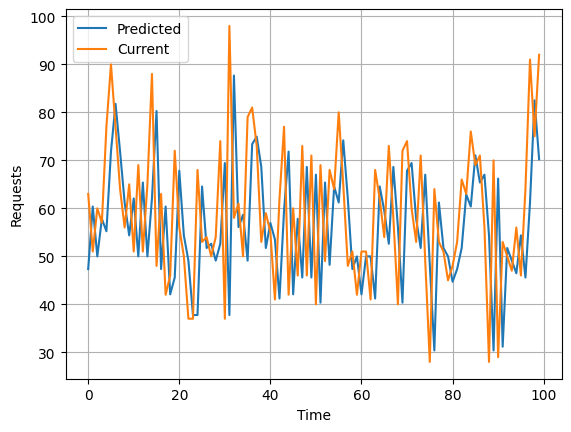

/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compilation Time :  0:00:00.000644
Training time :  0:00:16.152989
Training time :  0:00:16.152989
Samples 5295
Trainscore: 64.95
Test time:  0:00:00.063462
Timer:  0:00:16.555874
Filename: ./http_requests_nasa/trace5.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  128
LAYER2:  64
R2:  0.7793464064598083
Testscore: 3087.68 MSE (55.57 RMSE)
MAE: 43.28
Samples 5295
Trainscore: 64.95
Test time:  0:00:00.063462
Timer:  0:00:16.555874
Filename: ./http_requests_nasa/trace5.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  128
LAYER2:  64
R2:  0.7793464064598083
Testscore: 3087.68 MSE (55.57 RMSE)
MAE: 43.28


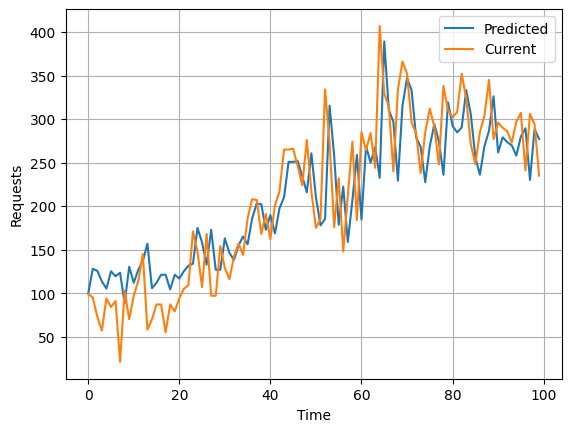

Compilation Time :  0:00:00.000777


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:05.759702
Samples 2646
Trainscore: 116.21
Test time:  0:00:00.039393
Timer:  0:00:06.084313
Filename: ./http_requests_nasa/trace10.csv
BATCH_SIZE: 140
NB_EPOCHS:  100
LAYER1:  16
LAYER2:  32
R2:  0.799467146396637
Testscore: 10634.50 MSE (103.12 RMSE)
MAE: 81.75
Samples 2646
Trainscore: 116.21
Test time:  0:00:00.039393
Timer:  0:00:06.084313
Filename: ./http_requests_nasa/trace10.csv
BATCH_SIZE: 140
NB_EPOCHS:  100
LAYER1:  16
LAYER2:  32
R2:  0.799467146396637
Testscore: 10634.50 MSE (103.12 RMSE)
MAE: 81.75


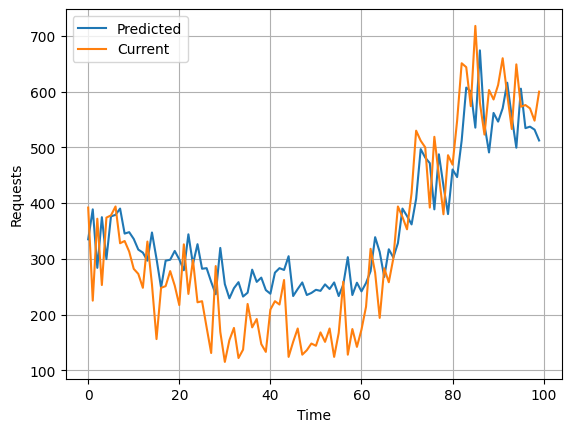

Compilation Time :  0:00:00.000700


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:08.986175
Samples 1763
Trainscore: 161.12
Test time:  0:00:00.036102
Timer:  0:00:09.295934
Filename: ./http_requests_nasa/trace15.csv
BATCH_SIZE: 140
NB_EPOCHS:  190
LAYER1:  5
LAYER2:  40
R2:  0.8127740621566772
Testscore: 21777.48 MSE (147.57 RMSE)
MAE: 117.57
Samples 1763
Trainscore: 161.12
Test time:  0:00:00.036102
Timer:  0:00:09.295934
Filename: ./http_requests_nasa/trace15.csv
BATCH_SIZE: 140
NB_EPOCHS:  190
LAYER1:  5
LAYER2:  40
R2:  0.8127740621566772
Testscore: 21777.48 MSE (147.57 RMSE)
MAE: 117.57


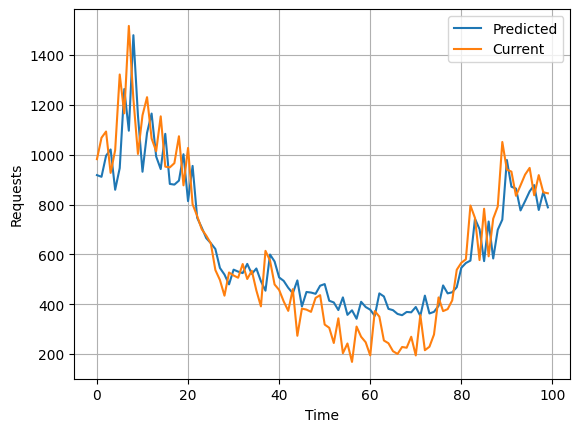

Compilation Time :  0:00:00.000649


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:09.079508
Samples 1321
Trainscore: 206.97
Test time:  0:00:00.032255
Timer:  0:00:09.382682
Filename: ./http_requests_nasa/trace20.csv
BATCH_SIZE: 140
NB_EPOCHS:  200
LAYER1:  50
LAYER2:  45
R2:  0.8228785395622253
Testscore: 36159.03 MSE (190.16 RMSE)
MAE: 149.61
Samples 1321
Trainscore: 206.97
Test time:  0:00:00.032255
Timer:  0:00:09.382682
Filename: ./http_requests_nasa/trace20.csv
BATCH_SIZE: 140
NB_EPOCHS:  200
LAYER1:  50
LAYER2:  45
R2:  0.8228785395622253
Testscore: 36159.03 MSE (190.16 RMSE)
MAE: 149.61


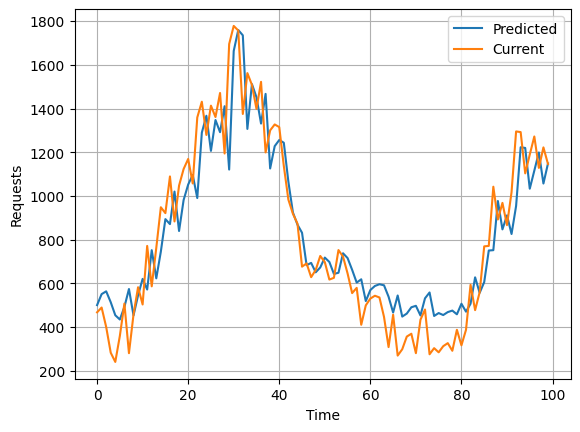

Compilation Time :  0:00:00.000656


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:09.010459
Samples 1057
Trainscore: 262.81
Test time:  0:00:00.033042
Timer:  0:00:09.325450
Filename: ./http_requests_nasa/trace25.csv
BATCH_SIZE: 180
NB_EPOCHS:  200
LAYER1:  10
LAYER2:  80
R2:  0.8309985399246216
Testscore: 52725.14 MSE (229.62 RMSE)
MAE: 183.47
Samples 1057
Trainscore: 262.81
Test time:  0:00:00.033042
Timer:  0:00:09.325450
Filename: ./http_requests_nasa/trace25.csv
BATCH_SIZE: 180
NB_EPOCHS:  200
LAYER1:  10
LAYER2:  80
R2:  0.8309985399246216
Testscore: 52725.14 MSE (229.62 RMSE)
MAE: 183.47


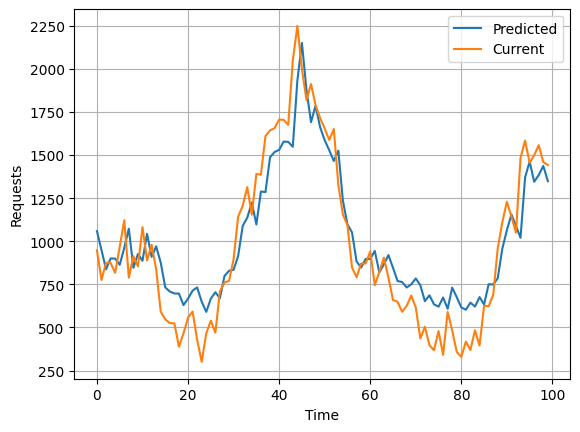

Compilation Time :  0:00:00.000899


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:07.194380
Samples 880
Trainscore: 312.58
Test time:  0:00:00.031288
Timer:  0:00:07.493800
Filename: ./http_requests_nasa/trace30.csv
BATCH_SIZE: 140
NB_EPOCHS:  190
LAYER1:  5
LAYER2:  40
R2:  0.8105098009109497
Testscore: 84970.99 MSE (291.50 RMSE)
MAE: 234.10
Samples 880
Trainscore: 312.58
Test time:  0:00:00.031288
Timer:  0:00:07.493800
Filename: ./http_requests_nasa/trace30.csv
BATCH_SIZE: 140
NB_EPOCHS:  190
LAYER1:  5
LAYER2:  40
R2:  0.8105098009109497
Testscore: 84970.99 MSE (291.50 RMSE)
MAE: 234.10


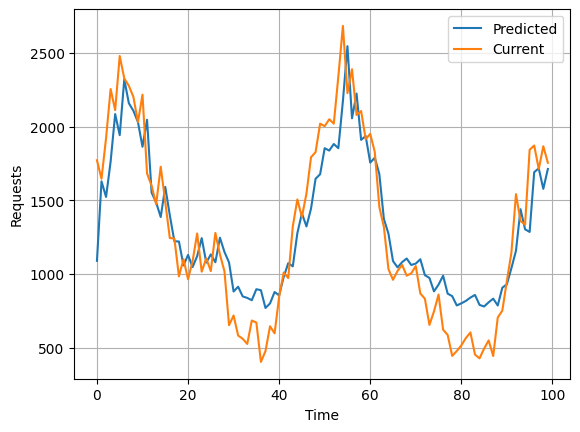

Compilation Time :  0:00:00.000660


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:07.862542
Samples 754
Trainscore: 371.62
Test time:  0:00:00.030155
Timer:  0:00:08.156945
Filename: ./http_requests_nasa/trace35.csv
BATCH_SIZE: 180
NB_EPOCHS:  200
LAYER1:  10
LAYER2:  80
R2:  0.8315973281860352
Testscore: 101448.30 MSE (318.51 RMSE)
MAE: 257.02
Samples 754
Trainscore: 371.62
Test time:  0:00:00.030155
Timer:  0:00:08.156945
Filename: ./http_requests_nasa/trace35.csv
BATCH_SIZE: 180
NB_EPOCHS:  200
LAYER1:  10
LAYER2:  80
R2:  0.8315973281860352
Testscore: 101448.30 MSE (318.51 RMSE)
MAE: 257.02


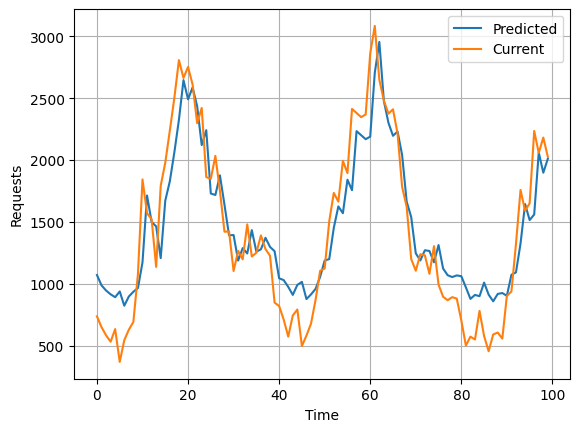

Compilation Time :  0:00:00.000696


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:07.894080
Samples 659
Trainscore: 424.64
Test time:  0:00:00.037700
Timer:  0:00:08.214809
Filename: ./http_requests_nasa/trace40.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  256
LAYER2:  32
R2:  0.833151638507843
Testscore: 131125.02 MSE (362.11 RMSE)
MAE: 282.90
Samples 659
Trainscore: 424.64
Test time:  0:00:00.037700
Timer:  0:00:08.214809
Filename: ./http_requests_nasa/trace40.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  256
LAYER2:  32
R2:  0.833151638507843
Testscore: 131125.02 MSE (362.11 RMSE)
MAE: 282.90


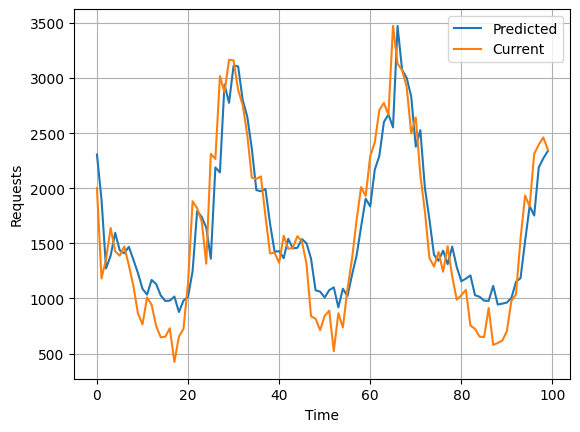

Compilation Time :  0:00:00.000745


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:06.116608
Samples 586
Trainscore: 494.96
Test time:  0:00:00.025625
Timer:  0:00:06.390780
Filename: ./http_requests_nasa/trace45.csv
BATCH_SIZE: 140
NB_EPOCHS:  150
LAYER1:  8
LAYER2:  64
R2:  0.7948141694068909
Testscore: 202372.48 MSE (449.86 RMSE)
MAE: 373.79
Samples 586
Trainscore: 494.96
Test time:  0:00:00.025625
Timer:  0:00:06.390780
Filename: ./http_requests_nasa/trace45.csv
BATCH_SIZE: 140
NB_EPOCHS:  150
LAYER1:  8
LAYER2:  64
R2:  0.7948141694068909
Testscore: 202372.48 MSE (449.86 RMSE)
MAE: 373.79


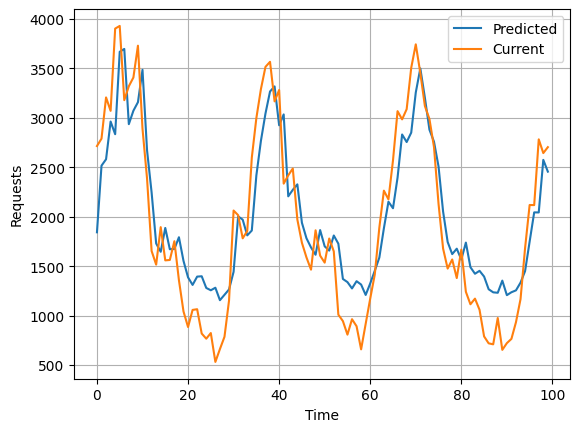

Compilation Time :  0:00:00.000668


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:05.751847
Samples 527
Trainscore: 569.48
Test time:  0:00:00.026426
Timer:  0:00:06.018753
Filename: ./http_requests_nasa/trace50.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  60
LAYER2:  60
R2:  0.8269351720809937
Testscore: 208577.98 MSE (456.70 RMSE)
MAE: 377.62
Samples 527
Trainscore: 569.48
Test time:  0:00:00.026426
Timer:  0:00:06.018753
Filename: ./http_requests_nasa/trace50.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  60
LAYER2:  60
R2:  0.8269351720809937
Testscore: 208577.98 MSE (456.70 RMSE)
MAE: 377.62


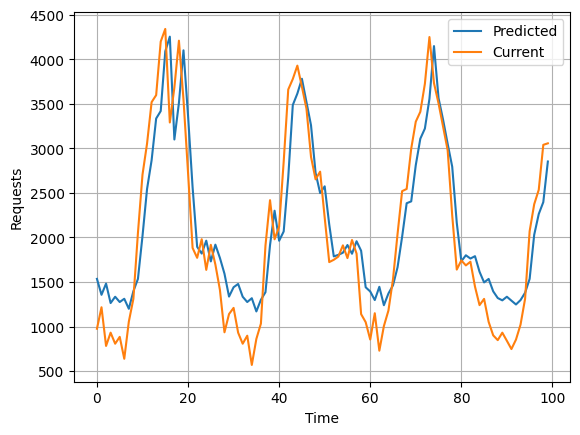

Compilation Time :  0:00:00.000703


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training time :  0:00:06.305145
Samples 479
Trainscore: 645.56
Test time:  0:00:00.029007
Timer:  0:00:06.617239
Filename: ./http_requests_nasa/trace55.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  128
LAYER2:  64
R2:  0.8138507604598999
Testscore: 271540.06 MSE (521.10 RMSE)
MAE: 433.82
Samples 479
Trainscore: 645.56
Test time:  0:00:00.029007
Timer:  0:00:06.617239
Filename: ./http_requests_nasa/trace55.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  128
LAYER2:  64
R2:  0.8138507604598999
Testscore: 271540.06 MSE (521.10 RMSE)
MAE: 433.82


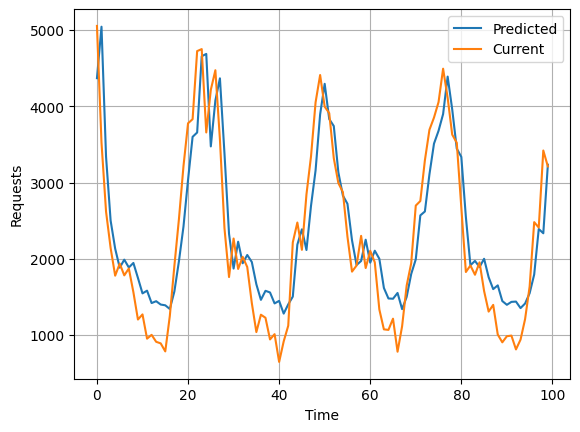

,dataset,batch_size,epochs,layer1,layer2,mae,mse,rmse,r2
0,./http_requests_nasa/trace1.csv,140,150,8,64,12.180,252.790,15.899,0.6342
1,./http_requests_nasa/trace5.csv,130,130,128,64,43.282,3087.681,55.567,0.7793
2,./http_requests_nasa/trace10.csv,140,100,16,32,81.751,10634.500,103.124,0.7995
3,./http_requests_nasa/trace15.csv,140,190,5,40,117.571,21777.479,147.572,0.8128
4,./http_requests_nasa/trace20.csv,140,200,50,45,149.609,36159.027,190.155,0.8229
5,./http_requests_nasa/trace25.csv,180,200,10,80,183.474,52725.137,229.620,0.8310
6,./http_requests_nasa/trace30.csv,140,190,5,40,234.099,84970.992,291.498,0.8105
7,./http_requests_nasa/trace35.csv,180,200,10,80,257.021,101448.305,318.510,0.8316
8,./http_requests_nasa/trace40.csv,130,130,256,32,282.897,131125.016,362.112,0.8332
9,./http_requests_nasa/trace45.csv,140,150,8,64,373.788,202372.484,449.858,0.7948


In [3]:
import pandas as pd

results = []
for params in hyperparameters:
    filename, BATCH_SIZE, NB_EPOCHS, LAYER1, LAYER2 = params
    result = gru(filename, BATCH_SIZE, NB_EPOCHS, LAYER1, LAYER2)
    results.append(result)

if results:
    summary_df = pd.DataFrame(results)
    summary_df = summary_df[["dataset", "batch_size", "epochs", "layer1", "layer2", "mae", "mse", "rmse", "r2"]]
    display(summary_df.round({"mae": 3, "mse": 3, "rmse": 3, "r2": 4}))